## Evaluation

In [1]:
from eval.segmentation import variation_of_information, mutual_information, evaluate_segmentation, compare_segmentations
from app.services.image_processing import segment_hough, segment_rect, read_image

In [2]:
img = read_image("images/bookshelf3.png", max_dim=1024)

Depth 0 | Split 1: score=0.409, direction=horizontal, pos=190, child ratios=0.24, 0.76
Depth 1 | Split 2: score=1.746, direction=vertical, pos=510, child ratios=0.85, 0.15
Depth 1 | Split 3: score=0.495, direction=horizontal, pos=240, child ratios=0.08, 0.92
Depth 2 | Split 4: score=0.382, direction=vertical, pos=30, child ratios=0.05, 0.95
Depth 3 | Split 5: score=0.306, direction=horizontal, pos=295, child ratios=0.10, 0.90
Depth 4 | Split 6: score=0.335, direction=vertical, pos=545, child ratios=0.90, 0.10
Depth 5 | Split 7: score=0.273, direction=vertical, pos=505, child ratios=0.92, 0.08
Depth 6 | Split 8: score=0.278, direction=vertical, pos=455, child ratios=0.89, 0.11
Depth 7 | Split 9: score=0.286, direction=vertical, pos=395, child ratios=0.86, 0.14
Depth 8 | Split 10: score=0.511, direction=vertical, pos=295, child ratios=0.73, 0.27
Depth 9 | Split 11: score=0.558, direction=horizontal, pos=330, child ratios=0.07, 0.93

Total segments: 11
Depth 0 | Split 1: score=0.430, chil

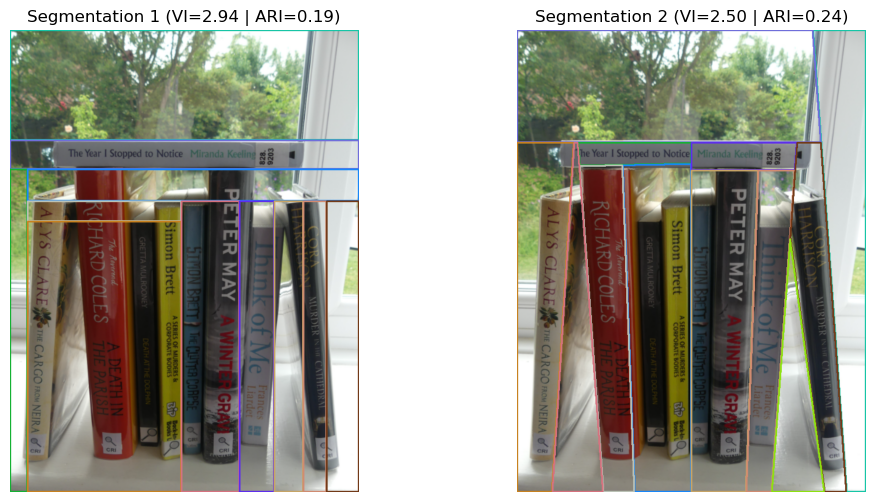

In [4]:
def segment_rect_configured(img):
    masks = segment_rect(img, verbose=True)
    return masks

def segment_hough_configured(img):
    masks = segment_hough(img, verbose=True, min_score=0.01, blur=False)
    return masks

compare_segmentations("images/eval", segmentation_function1=segment_rect_configured, segmentation_function2=segment_hough_configured, image_index=0)

In [5]:
def segment_rect_configured(img):
    masks = segment_rect(img, verbose=False)
    return masks

eval1 = evaluate_segmentation("images/eval", segment_rect_configured)

test_img_0.png: VI = 2.9426 | ARI = 0.1940
test_img_1.png: VI = 2.6045 | ARI = 0.2764
test_img_2.png: VI = 2.1570 | ARI = 0.3043

--------------------
Final Results
--------------------
VI:  2.5680 ± 0.3941
ARI: 0.2582 ± 0.0574


In [ ]:
def segment_hough_configured(img):
    masks = segment_hough(img, verbose=False, max_depth=10, min_score=0.01, nlm_h=20, nlm_patch_size=15, nlm_search_size=45)
    return masks

eval2 = evaluate_segmentation("images/eval", segment_hough_configured)

test_img_0.png: VI = 2.5010 | ARI = 0.2554
test_img_1.png: VI = 2.3402 | ARI = 0.3065
test_img_2.png: VI = 2.6445 | ARI = 0.2560

--------------------
Final Results
--------------------
VI:  2.4952 ± 0.1522
ARI: 0.2726 ± 0.0293
